# Variational Quantum Eigensolver (VQE) for Single-Qubit Systems

This notebook implements the **Variational Quantum Eigensolver (VQE)** algorithm for a general single-qubit Hamiltonian. Any $2 \times 2$ Hermitian matrix can be decomposed in terms of Pauli matrices:

$$H = h_I I + h_X X + h_Y Y + h_Z Z$$

where $I, X, Y, Z$ are the identity and Pauli matrices, and $h_I, h_X, h_Y, h_Z \in \mathbb{R}$.

Alternatively, for a general $2 \times 2$ Hermitian matrix:

$$H = \begin{pmatrix} a & c - id \\ c + id & b \end{pmatrix}$$

where $a, b, c, d \in \mathbb{R}$, we can write:

$$h_I = \frac{a + b}{2}, \quad h_X = c, \quad h_Y = d, \quad h_Z = \frac{a - b}{2}$$

## VQE for Single Qubit:

1. **Ansatz**: $|\psi(\theta)\rangle = U(\theta)|0\rangle$ where $U(\theta) = R_z(\theta_2)R_y(\theta_1)R_z(\theta_0)$
2. **Measure**: $E(\theta) = \langle\psi(\theta)|H|\psi(\theta)\rangle$
3. **Optimize**: Find $\theta^*$ that minimizes $E(\theta)$
4. **Result**: Ground state energy and wavefunction

This demonstrates VQE on the simplest possible quantum system!

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Pauli Matrices and Quantum Gates

The Pauli matrices form a complete basis for $2 \times 2$ Hermitian matrices.

In [2]:
# Pauli matrices
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

print("Pauli Matrices:\n")
print(f"I (Identity):\n{I}\n")
print(f"X (Pauli-X):\n{X}\n")
print(f"Y (Pauli-Y):\n{Y}\n")
print(f"Z (Pauli-Z):\n{Z}\n")

# Verify key properties
print("Key Properties:")
print(f"X² = I: {np.allclose(X @ X, I)}")
print(f"Y² = I: {np.allclose(Y @ Y, I)}")
print(f"Z² = I: {np.allclose(Z @ Z, I)}")
print(f"XYZ = iI: {np.allclose(X @ Y @ Z, 1j * I)}")

Pauli Matrices:

I (Identity):
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

X (Pauli-X):
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

Y (Pauli-Y):
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

Z (Pauli-Z):
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

Key Properties:
X² = I: True
Y² = I: True
Z² = I: True
XYZ = iI: True


In [3]:
# Quantum rotation gates
def Rx(theta):
    """Rotation around X-axis: Rx(θ) = exp(-iθX/2)"""
    return np.array([
        [np.cos(theta/2), -1j*np.sin(theta/2)],
        [-1j*np.sin(theta/2), np.cos(theta/2)]
    ], dtype=complex)

def Ry(theta):
    """Rotation around Y-axis: Ry(θ) = exp(-iθY/2)"""
    return np.array([
        [np.cos(theta/2), -np.sin(theta/2)],
        [np.sin(theta/2), np.cos(theta/2)]
    ], dtype=complex)

def Rz(theta):
    """Rotation around Z-axis: Rz(θ) = exp(-iθZ/2)"""
    return np.array([
        [np.exp(-1j*theta/2), 0],
        [0, np.exp(1j*theta/2)]
    ], dtype=complex)

def Hadamard():
    """Hadamard gate: creates superposition."""
    return np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

print("Quantum gates defined:")
print("  • Rx(θ) - Rotation around X-axis")
print("  • Ry(θ) - Rotation around Y-axis")
print("  • Rz(θ) - Rotation around Z-axis")
print("  • H     - Hadamard gate")

# Test
H_gate = Hadamard()
print(f"\nHadamard matrix:\n{H_gate}")

Quantum gates defined:
  • Rx(θ) - Rotation around X-axis
  • Ry(θ) - Rotation around Y-axis
  • Rz(θ) - Rotation around Z-axis
  • H     - Hadamard gate

Hadamard matrix:
[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]


## 2. Hamiltonian Construction and Decomposition

First we:
1. Create a general $2 \times 2$ Hermitian matrix
2. Decompose it into Pauli components
3. Reconstruct from Pauli decomposition

In [4]:
def pauli_decomposition(H):
    """
    Decompose a 2×2 Hermitian matrix into Pauli components.
    
    H = h_I I + h_X X + h_Y Y + h_Z Z
    
    Parameters:
    -----------
    H : ndarray (2x2)
        Hermitian matrix
    
    Returns:
    --------
    coeffs : dict
        Dictionary with keys 'I', 'X', 'Y', 'Z'
    """
    # Use trace formula: h_P = Tr(P H) / 2
    h_I = np.real(np.trace(I @ H)) / 2
    h_X = np.real(np.trace(X @ H)) / 2
    h_Y = np.real(np.trace(Y @ H)) / 2
    h_Z = np.real(np.trace(Z @ H)) / 2
    
    return {'I': h_I, 'X': h_X, 'Y': h_Y, 'Z': h_Z}

def pauli_reconstruction(coeffs):
    """
    Reconstruct Hamiltonian from Pauli coefficients.
    """
    H = (coeffs['I'] * I + 
         coeffs['X'] * X + 
         coeffs['Y'] * Y + 
         coeffs['Z'] * Z)
    return H

def create_general_hamiltonian(a, b, c, d):
    """
    Create a general 2×2 Hermitian matrix.
    
    H = [[a,     c-id],
         [c+id,  b   ]]
    
    Parameters:
    -----------
    a, b, c, d : float
        Real parameters
    """
    H = np.array([
        [a, c - 1j*d],
        [c + 1j*d, b]
    ], dtype=complex)
    return H

# Example: Create a Hamiltonian
print("Example Hamiltonian Construction:\n")

# Method 1: From Pauli coefficients
coeffs_example = {'I': 0.5, 'X': 0.3, 'Y': 0.2, 'Z': 0.7}
H_pauli = pauli_reconstruction(coeffs_example)

print("From Pauli coefficients:")
print(f"  h_I = {coeffs_example['I']}")
print(f"  h_X = {coeffs_example['X']}")
print(f"  h_Y = {coeffs_example['Y']}")
print(f"  h_Z = {coeffs_example['Z']}")
print(f"\nH =\n{H_pauli}\n")

# Verify decomposition
coeffs_check = pauli_decomposition(H_pauli)
print("Verification (decompose → reconstruct):")
print(f"  Coefficients match: {np.allclose(list(coeffs_example.values()), list(coeffs_check.values()))}")

Example Hamiltonian Construction:

From Pauli coefficients:
  h_I = 0.5
  h_X = 0.3
  h_Y = 0.2
  h_Z = 0.7

H =
[[ 1.2+0.j   0.3-0.2j]
 [ 0.3+0.2j -0.2+0.j ]]

Verification (decompose → reconstruct):
  Coefficients match: True


### Define Specific Hamiltonian for VQE

Let's work with a non-trivial example.

In [5]:
# Define Hamiltonian parameters
# Example: General Hamiltonian with all Pauli components
h_I = 1.0
h_X = 0.5
h_Y = 0.3
h_Z = 0.8

# Construct Hamiltonian
pauli_coeffs = {'I': h_I, 'X': h_X, 'Y': h_Y, 'Z': h_Z}
H = pauli_reconstruction(pauli_coeffs)

print("="*60)
print("SINGLE-QUBIT HAMILTONIAN")
print("="*60)
print(f"\nPauli Decomposition:")
print(f"  H = {h_I:.3f} I + {h_X:.3f} X + {h_Y:.3f} Y + {h_Z:.3f} Z")
print(f"\nMatrix Form:")
print(H)
print(f"\nIs Hermitian: {np.allclose(H, H.conj().T)}")

# Exact solution
evals_exact, evecs_exact = np.linalg.eigh(H)
E_ground = evals_exact[0]
E_excited = evals_exact[1]
psi_ground = evecs_exact[:, 0]
psi_excited = evecs_exact[:, 1]

print(f"\n" + "="*60)
print("EXACT SOLUTION")
print("="*60)
print(f"Ground state energy:  E₀ = {E_ground:+.10f}")
print(f"Excited state energy: E₁ = {E_excited:+.10f}")
print(f"Energy gap:           ΔE = {E_excited - E_ground:.10f}")

print(f"\nGround state wavefunction:")
print(f"  |ψ₀⟩ = {psi_ground[0].real:+.6f}{psi_ground[0].imag:+.6f}j |0⟩ + {psi_ground[1].real:+.6f}{psi_ground[1].imag:+.6f}j |1⟩")
print(f"\nExcited state wavefunction:")
print(f"  |ψ₁⟩ = {psi_excited[0].real:+.6f}{psi_excited[0].imag:+.6f}j |0⟩ + {psi_excited[1].real:+.6f}{psi_excited[1].imag:+.6f}j |1⟩")

SINGLE-QUBIT HAMILTONIAN

Pauli Decomposition:
  H = 1.000 I + 0.500 X + 0.300 Y + 0.800 Z

Matrix Form:
[[1.8+0.j  0.5-0.3j]
 [0.5+0.3j 0.2+0.j ]]

Is Hermitian: True

EXACT SOLUTION
Ground state energy:  E₀ = +0.0100505063
Excited state energy: E₁ = +1.9899494937
Energy gap:           ΔE = 1.9798989873

Ground state wavefunction:
  |ψ₀⟩ = -0.309740+0.000000j |0⟩ + +0.815322+0.489193j |1⟩

Excited state wavefunction:
  |ψ₁⟩ = -0.950821+0.000000j |0⟩ + -0.265600-0.159360j |1⟩


### Visualize on Bloch Sphere

Any single-qubit state can be represented on the **Bloch sphere**:

$$|\psi\rangle = \cos(\theta/2)|0\rangle + e^{i\phi}\sin(\theta/2)|1\rangle$$

Bloch vector: $(\sin\theta\cos\phi, \sin\theta\sin\phi, \cos\theta)$

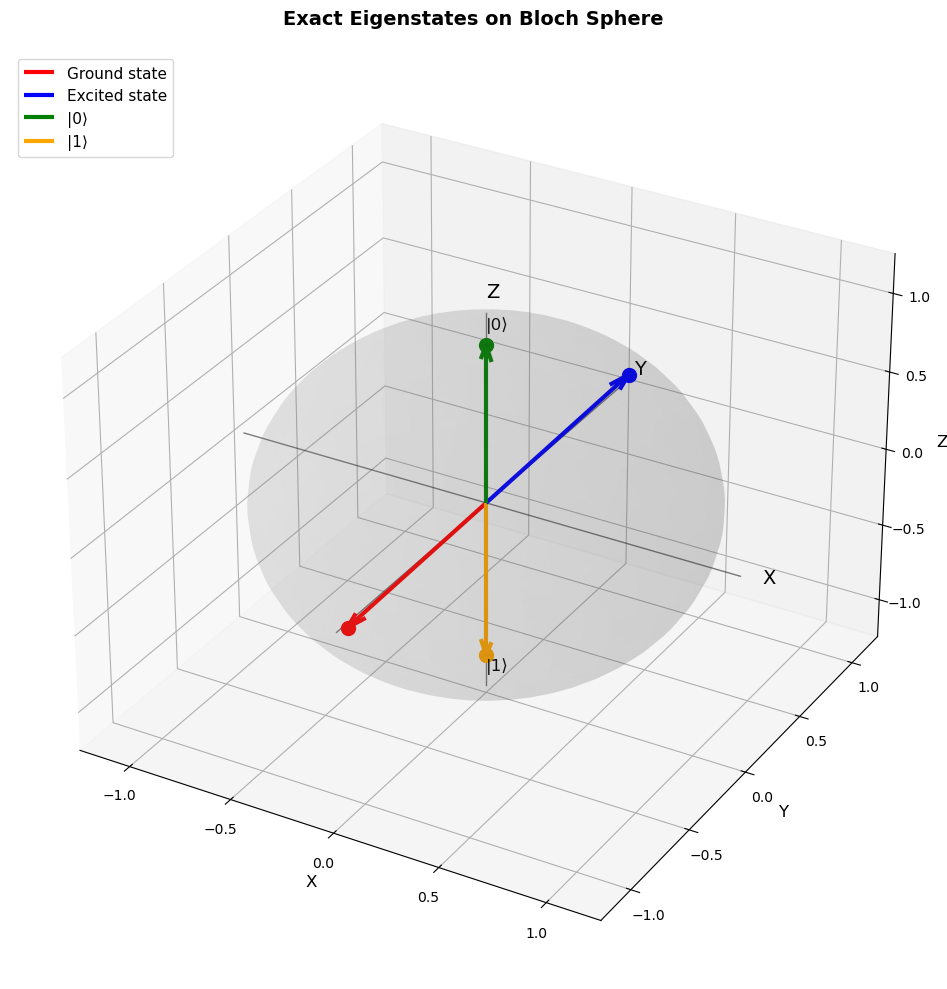

In [6]:
def state_to_bloch(psi):
    """
    Convert quantum state to Bloch sphere coordinates.
    
    Returns:
    --------
    x, y, z : float
        Bloch sphere coordinates
    theta, phi : float
        Spherical angles
    """
    # Normalize
    psi = psi / np.linalg.norm(psi)
    
    # Extract coefficients
    alpha = psi[0]
    beta = psi[1]
    
    # Compute Bloch vector components
    x = 2 * np.real(np.conj(alpha) * beta)
    y = 2 * np.imag(np.conj(alpha) * beta)
    z = np.abs(alpha)**2 - np.abs(beta)**2
    
    # Compute angles
    theta = 2 * np.arccos(np.abs(alpha))
    if np.abs(beta) > 1e-10:
        phi = np.angle(beta / alpha) if np.abs(alpha) > 1e-10 else np.angle(beta)
    else:
        phi = 0.0
    
    return x, y, z, theta, phi

def plot_bloch_sphere(states, labels, colors=None, title="Bloch Sphere"):
    """
    Plot states on the Bloch sphere.
    """
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Draw sphere
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    x_sphere = np.outer(np.cos(u), np.sin(v))
    y_sphere = np.outer(np.sin(u), np.sin(v))
    z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(x_sphere, y_sphere, z_sphere, alpha=0.1, color='gray')
    
    # Draw axes
    ax.plot([-1.2, 1.2], [0, 0], [0, 0], 'k-', linewidth=1, alpha=0.5)
    ax.plot([0, 0], [-1.2, 1.2], [0, 0], 'k-', linewidth=1, alpha=0.5)
    ax.plot([0, 0], [0, 0], [-1.2, 1.2], 'k-', linewidth=1, alpha=0.5)
    
    # Labels
    ax.text(1.3, 0, 0, 'X', fontsize=14)
    ax.text(0, 1.3, 0, 'Y', fontsize=14)
    ax.text(0, 0, 1.3, 'Z', fontsize=14)
    ax.text(0, 0, 1.1, '|0⟩', fontsize=12)
    ax.text(0, 0, -1.1, '|1⟩', fontsize=12)
    
    # Plot states
    if colors is None:
        colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    for i, (psi, label) in enumerate(zip(states, labels)):
        x, y, z, theta, phi = state_to_bloch(psi)
        color = colors[i % len(colors)]
        
        # Plot vector
        ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.1, linewidth=3, label=label)
        ax.scatter([x], [y], [z], color=color, s=100)
    
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_zlabel('Z', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.legend(fontsize=11, loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Visualize exact eigenstates
plot_bloch_sphere(
    [psi_ground, psi_excited, np.array([1, 0]), np.array([0, 1])],
    ['Ground state', 'Excited state', '|0⟩', '|1⟩'],
    colors=['red', 'blue', 'green', 'orange'],
    title='Exact Eigenstates on Bloch Sphere'
)

## 3. Quantum Circuit Ansatz

For a single qubit, we use the **universal single-qubit gate**:

$$U(\theta_0, \theta_1, \theta_2) = R_z(\theta_2) R_y(\theta_1) R_z(\theta_0)$$

This can generate any single-qubit state from $|0\rangle$:

$$|\psi(\theta)\rangle = U(\theta_0, \theta_1, \theta_2)|0\rangle$$

**Properties:**
- **Universal**: Can reach any point on Bloch sphere
- **3 parameters**: Minimal for full coverage
- **Efficient**: Standard decomposition used in quantum compilers

In [7]:
def prepare_ansatz(theta0, theta1, theta2):
    """
    Universal single-qubit ansatz: U = Rz(θ₂) Ry(θ₁) Rz(θ₀)
    
    This is the standard decomposition that can generate any
    single-qubit unitary.
    """
    U = Rz(theta2) @ Ry(theta1) @ Rz(theta0)
    return U

def prepare_state(params):
    """
    Prepare state |ψ(θ)⟩ = U(θ₀, θ₁, θ₂)|0⟩
    
    Parameters:
    -----------
    params : array-like of length 3
        [θ₀, θ₁, θ₂]
    """
    U = prepare_ansatz(params[0], params[1], params[2])
    psi_0 = np.array([1.0, 0.0], dtype=complex)  # |0⟩
    psi = U @ psi_0
    return psi

# Test ansatz
test_params = [np.pi/4, np.pi/3, np.pi/6]
psi_test = prepare_state(test_params)

print("Ansatz Circuit: U = Rz(θ₂) Ry(θ₁) Rz(θ₀)")
print(f"\nTest parameters: θ = [{test_params[0]:.4f}, {test_params[1]:.4f}, {test_params[2]:.4f}]")
print(f"\nTest state:")
print(f"  |ψ⟩ = {psi_test[0].real:+.4f}{psi_test[0].imag:+.4f}j |0⟩ + {psi_test[1].real:+.4f}{psi_test[1].imag:+.4f}j |1⟩")
print(f"\nNorm check: {np.linalg.norm(psi_test):.10f} (should be 1.0)")

Ansatz Circuit: U = Rz(θ₂) Ry(θ₁) Rz(θ₀)

Test parameters: θ = [0.7854, 1.0472, 0.5236]

Test state:
  |ψ⟩ = +0.6871-0.5272j |0⟩ + +0.4957-0.0653j |1⟩

Norm check: 1.0000000000 (should be 1.0)


### Visualize Circuit

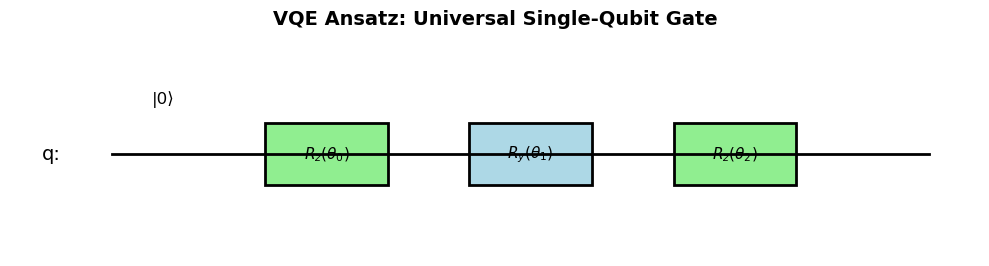

In [8]:
from matplotlib.patches import Rectangle

def draw_single_qubit_circuit():
    """Draw the VQE ansatz circuit for single qubit."""
    fig, ax = plt.subplots(figsize=(10, 3))
    
    # Circuit line
    ax.plot([0, 8], [1, 1], 'k-', linewidth=2)
    
    # Label
    ax.text(-0.5, 1, 'q:', fontsize=14, ha='right', va='center')
    ax.text(0.5, 1.5, '|0⟩', fontsize=12, ha='center')
    
    # Rz(θ₀)
    rect = Rectangle((1.5, 0.7), 1.2, 0.6, facecolor='lightgreen', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(2.1, 1, r'$R_z(\theta_0)$', fontsize=11, ha='center', va='center')
    
    # Ry(θ₁)
    rect = Rectangle((3.5, 0.7), 1.2, 0.6, facecolor='lightblue', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(4.1, 1, r'$R_y(\theta_1)$', fontsize=11, ha='center', va='center')
    
    # Rz(θ₂)
    rect = Rectangle((5.5, 0.7), 1.2, 0.6, facecolor='lightgreen', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(6.1, 1, r'$R_z(\theta_2)$', fontsize=11, ha='center', va='center')
    
    ax.set_xlim(-1, 8.5)
    ax.set_ylim(0, 2)
    ax.axis('off')
    ax.set_aspect('equal')
    ax.set_title('VQE Ansatz: Universal Single-Qubit Gate', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

draw_single_qubit_circuit()

## 4. Quantum Measurements

To measure the energy, we need to measure each Pauli term:

$$E = h_I\langle I \rangle + h_X\langle X \rangle + h_Y\langle Y \rangle + h_Z\langle Z \rangle$$

In [9]:
def measure_pauli(psi, pauli_op, pauli_name):
    """
    Measure expectation value ⟨ψ|P|ψ⟩ for Pauli operator P.
    
    On real hardware, this requires:
    - Basis rotation (for X, Y)
    - Measurement in computational (Z) basis
    - Statistical sampling
    """
    expectation = np.real(np.vdot(psi, pauli_op @ psi))
    return expectation

def measure_energy(psi, pauli_coeffs):
    """
    Measure total energy by measuring each Pauli term.
    """
    E_I = pauli_coeffs['I'] * measure_pauli(psi, I, 'I')
    E_X = pauli_coeffs['X'] * measure_pauli(psi, X, 'X')
    E_Y = pauli_coeffs['Y'] * measure_pauli(psi, Y, 'Y')
    E_Z = pauli_coeffs['Z'] * measure_pauli(psi, Z, 'Z')
    
    E_total = E_I + E_X + E_Y + E_Z
    return E_total

# Test measurements on exact ground state
print("Measurements on Exact Ground State:\n")
print(f"{'Pauli':>5s} | {'Coefficient':>12s} | {'⟨P⟩':>12s} | {'Contribution':>14s}")
print("-" * 55)

measurements = {}
contributions = {}
for P_name, P_op in [('I', I), ('X', X), ('Y', Y), ('Z', Z)]:
    coeff = pauli_coeffs[P_name]
    exp_val = measure_pauli(psi_ground, P_op, P_name)
    contrib = coeff * exp_val
    measurements[P_name] = exp_val
    contributions[P_name] = contrib
    print(f"{P_name:>5s} | {coeff:+12.6f} | {exp_val:+12.6f} | {contrib:+14.6f}")

E_measured = measure_energy(psi_ground, pauli_coeffs)
print("-" * 55)
print(f"{'Total':>5s} | {'':>12s} | {'':>12s} | {E_measured:+14.6f}")
print(f"\nExact energy: {E_ground:+14.6f}")
print(f"Difference:   {abs(E_measured - E_ground):.2e}")

Measurements on Exact Ground State:

Pauli |  Coefficient |          ⟨P⟩ |   Contribution
-------------------------------------------------------
    I |    +1.000000 |    +1.000000 |      +1.000000
    X |    +0.500000 |    -0.505076 |      -0.252538
    Y |    +0.300000 |    -0.303046 |      -0.090914
    Z |    +0.800000 |    -0.808122 |      -0.646498
-------------------------------------------------------
Total |              |              |      +0.010051

Exact energy:      +0.010051
Difference:   1.60e-16


## 5. VQE Optimization

Now we implement the VQE algorithm to find the ground state.

In [10]:
class SingleQubitVQE:
    """VQE for single-qubit Hamiltonian."""
    
    def __init__(self, hamiltonian, pauli_coeffs):
        self.H = hamiltonian
        self.pauli_coeffs = pauli_coeffs
        self.energy_history = []
        self.param_history = []
        self.state_history = []
        self.n_evaluations = 0
    
    def energy_evaluation(self, params):
        """Evaluate energy for given parameters."""
        # Prepare quantum state
        psi = prepare_state(params)
        
        # Measure energy
        energy = measure_energy(psi, self.pauli_coeffs)
        
        # Store history
        self.energy_history.append(energy)
        self.param_history.append(params.copy())
        self.state_history.append(psi.copy())
        self.n_evaluations += 1
        
        return energy
    
    def optimize(self, initial_params=None, method='COBYLA', maxiter=100):
        """Run VQE optimization."""
        if initial_params is None:
            initial_params = np.random.uniform(0, 2*np.pi, 3)
        
        print(f"Starting VQE optimization...")
        print(f"  Method: {method}")
        print(f"  Initial parameters: {initial_params}")
        
        # Reset counters
        self.energy_history = []
        self.param_history = []
        self.state_history = []
        self.n_evaluations = 0
        
        # Optimize
        result = minimize(
            self.energy_evaluation,
            initial_params,
            method=method,
            options={'maxiter': maxiter, 'disp': False}
        )
        
        print(f"\nOptimization complete!")
        print(f"  Function evaluations: {self.n_evaluations}")
        print(f"  Final energy: {result.fun:.10f}")
        print(f"  Optimal parameters: {result.x}")
        
        return result

print("VQE class defined.")

VQE class defined.


### Run VQE

In [11]:
# Create VQE instance
vqe = SingleQubitVQE(H, pauli_coeffs)

# Run optimization
result = vqe.optimize(method='COBYLA', maxiter=100)

# Get VQE results
E_vqe = result.fun
params_opt = result.x
psi_vqe = prepare_state(params_opt)

# Calculate fidelity
fidelity = np.abs(np.vdot(psi_ground, psi_vqe))**2

print("\n" + "="*70)
print("VQE RESULTS")
print("="*70)
print(f"\nExact ground state energy: {E_ground:.10f}")
print(f"VQE ground state energy:   {E_vqe:.10f}")
print(f"\nAbsolute error:  {abs(E_vqe - E_ground):.2e}")
print(f"Relative error:  {abs(E_vqe - E_ground)/abs(E_ground)*100:.6f}%")
print(f"\nFidelity with exact ground state: {fidelity:.10f}")
print(f"Infidelity: {1-fidelity:.2e}")

print(f"\nOptimal parameters:")
print(f"  θ₀ = {params_opt[0]:.6f} rad = {np.degrees(params_opt[0]):.2f}°")
print(f"  θ₁ = {params_opt[1]:.6f} rad = {np.degrees(params_opt[1]):.2f}°")
print(f"  θ₂ = {params_opt[2]:.6f} rad = {np.degrees(params_opt[2]):.2f}°")

Starting VQE optimization...
  Method: COBYLA
  Initial parameters: [2.35330497 5.97351416 4.59925358]

Optimization complete!
  Function evaluations: 49
  Final energy: 0.0100505075
  Optimal parameters: [3.18302597 8.79492382 3.68193455]

VQE RESULTS

Exact ground state energy: 0.0100505063
VQE ground state energy:   0.0100505075

Absolute error:  1.14e-09
Relative error:  0.000011%

Fidelity with exact ground state: 0.9999999994
Infidelity: 5.76e-10

Optimal parameters:
  θ₀ = 3.183026 rad = 182.37°
  θ₁ = 8.794924 rad = 503.91°
  θ₂ = 3.681935 rad = 210.96°


## 6. Analysis and Visualization

In [12]:
# State comparison
print("State Comparison:\n")
print(f"{'Basis':>6s} | {'Exact (real)':>12s} | {'Exact (imag)':>12s} | {'VQE (real)':>12s} | {'VQE (imag)':>12s}")
print("-" * 70)
for i in range(2):
    basis = f"|{i}⟩"
    print(f"{basis:>6s} | {psi_ground[i].real:+12.6f} | {psi_ground[i].imag:+12.6f} | {psi_vqe[i].real:+12.6f} | {psi_vqe[i].imag:+12.6f}")

# Bloch sphere representation
x_ex, y_ex, z_ex, _, _ = state_to_bloch(psi_ground)
x_vqe, y_vqe, z_vqe, _, _ = state_to_bloch(psi_vqe)

print(f"\nBloch Sphere Coordinates:")
print(f"{'State':>12s} | {'x':>10s} | {'y':>10s} | {'z':>10s}")
print("-" * 50)
print(f"{'Exact':>12s} | {x_ex:+10.6f} | {y_ex:+10.6f} | {z_ex:+10.6f}")
print(f"{'VQE':>12s} | {x_vqe:+10.6f} | {y_vqe:+10.6f} | {z_vqe:+10.6f}")
print(f"{'Difference':>12s} | {abs(x_ex-x_vqe):10.6f} | {abs(y_ex-y_vqe):10.6f} | {abs(z_ex-z_vqe):10.6f}")

State Comparison:

 Basis | Exact (real) | Exact (imag) |   VQE (real) |   VQE (imag)
----------------------------------------------------------------------
   |0⟩ |    -0.309740 |    +0.000000 |    +0.296735 |    -0.088836
   |1⟩ |    +0.815322 |    +0.489193 |    -0.921389 |    -0.234734

Bloch Sphere Coordinates:
       State |          x |          y |          z
--------------------------------------------------
       Exact |  -0.505076 |  -0.303046 |  -0.808122
         VQE |  -0.505110 |  -0.303013 |  -0.808113
  Difference |   0.000034 |   0.000033 |   0.000009


### Convergence Plots

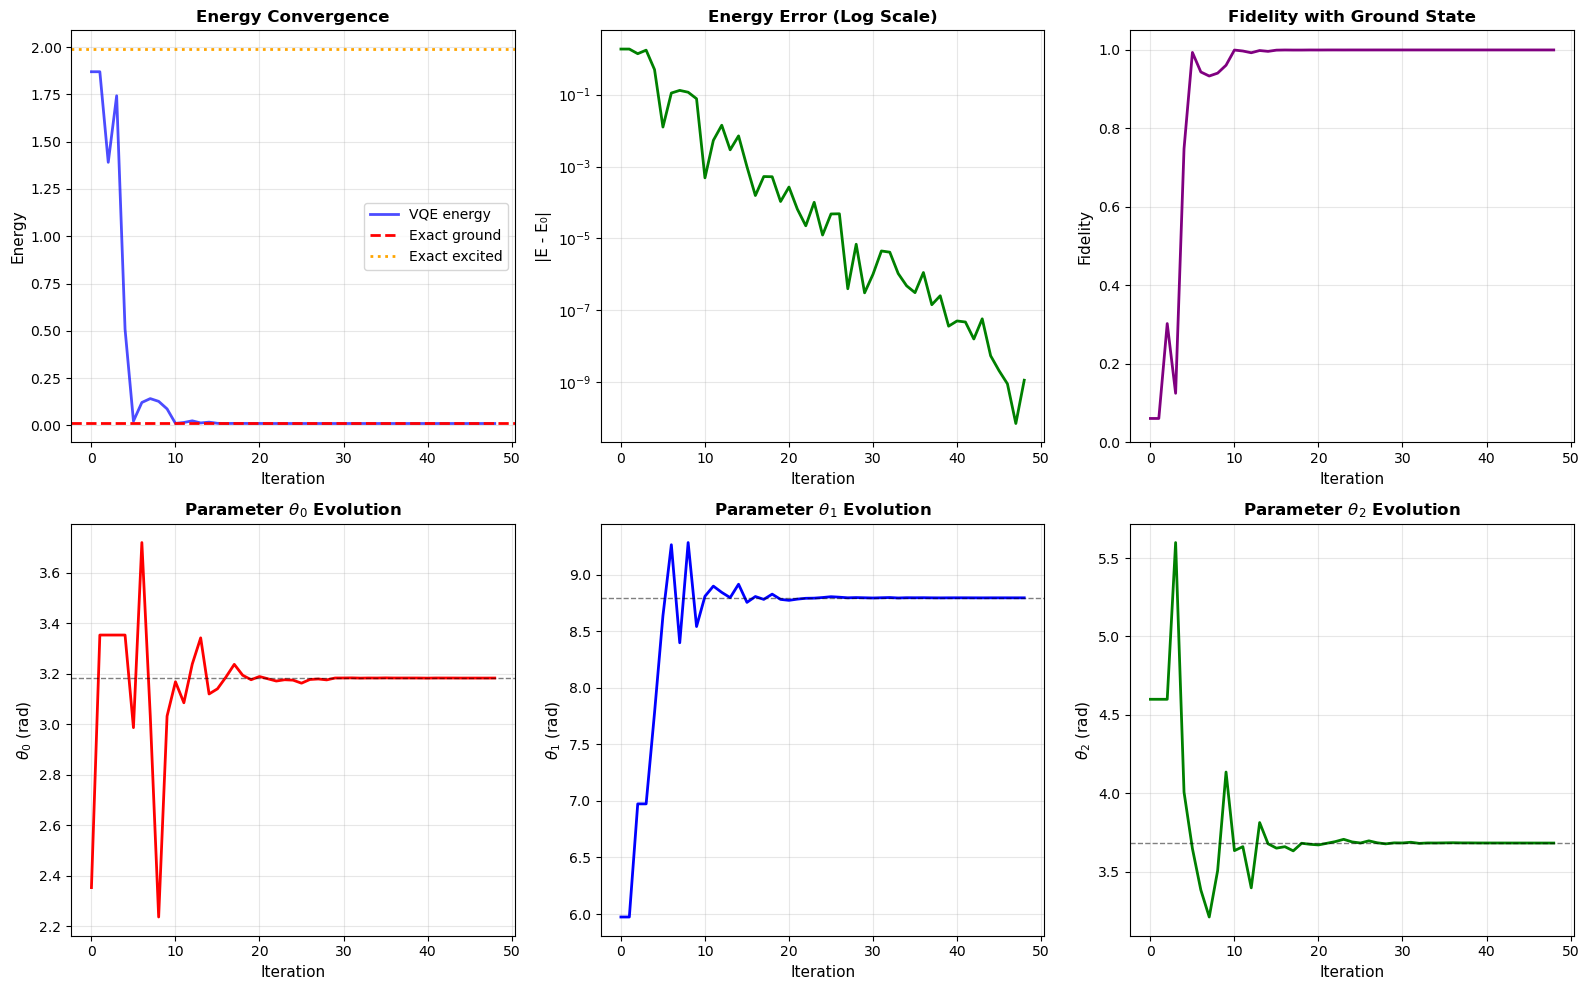

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Energy convergence
ax1 = axes[0, 0]
ax1.plot(vqe.energy_history, 'b-', linewidth=2, alpha=0.7, label='VQE energy')
ax1.axhline(y=E_ground, color='r', linestyle='--', linewidth=2, label='Exact ground')
ax1.axhline(y=E_excited, color='orange', linestyle=':', linewidth=2, label='Exact excited')
ax1.set_xlabel('Iteration', fontsize=11)
ax1.set_ylabel('Energy', fontsize=11)
ax1.set_title('Energy Convergence', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Error (log scale)
ax2 = axes[0, 1]
errors = [abs(E - E_ground) for E in vqe.energy_history]
ax2.semilogy(errors, 'g-', linewidth=2)
ax2.set_xlabel('Iteration', fontsize=11)
ax2.set_ylabel('|E - E₀|', fontsize=11)
ax2.set_title('Energy Error (Log Scale)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

# Plot 3: Fidelity evolution
ax3 = axes[0, 2]
fidelities = [np.abs(np.vdot(psi_ground, psi))**2 for psi in vqe.state_history]
ax3.plot(fidelities, 'purple', linewidth=2)
ax3.set_xlabel('Iteration', fontsize=11)
ax3.set_ylabel('Fidelity', fontsize=11)
ax3.set_title('Fidelity with Ground State', fontsize=12, fontweight='bold')
ax3.set_ylim([0, 1.05])
ax3.grid(True, alpha=0.3)

# Plot 4-6: Parameter evolution
param_array = np.array(vqe.param_history)
param_labels = [r'$\theta_0$', r'$\theta_1$', r'$\theta_2$']
colors_params = ['red', 'blue', 'green']

for i in range(3):
    ax = axes[1, i]
    ax.plot(param_array[:, i], color=colors_params[i], linewidth=2)
    ax.axhline(y=params_opt[i], color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel(f'{param_labels[i]} (rad)', fontsize=11)
    ax.set_title(f'Parameter {param_labels[i]} Evolution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Trajectory on Bloch Sphere

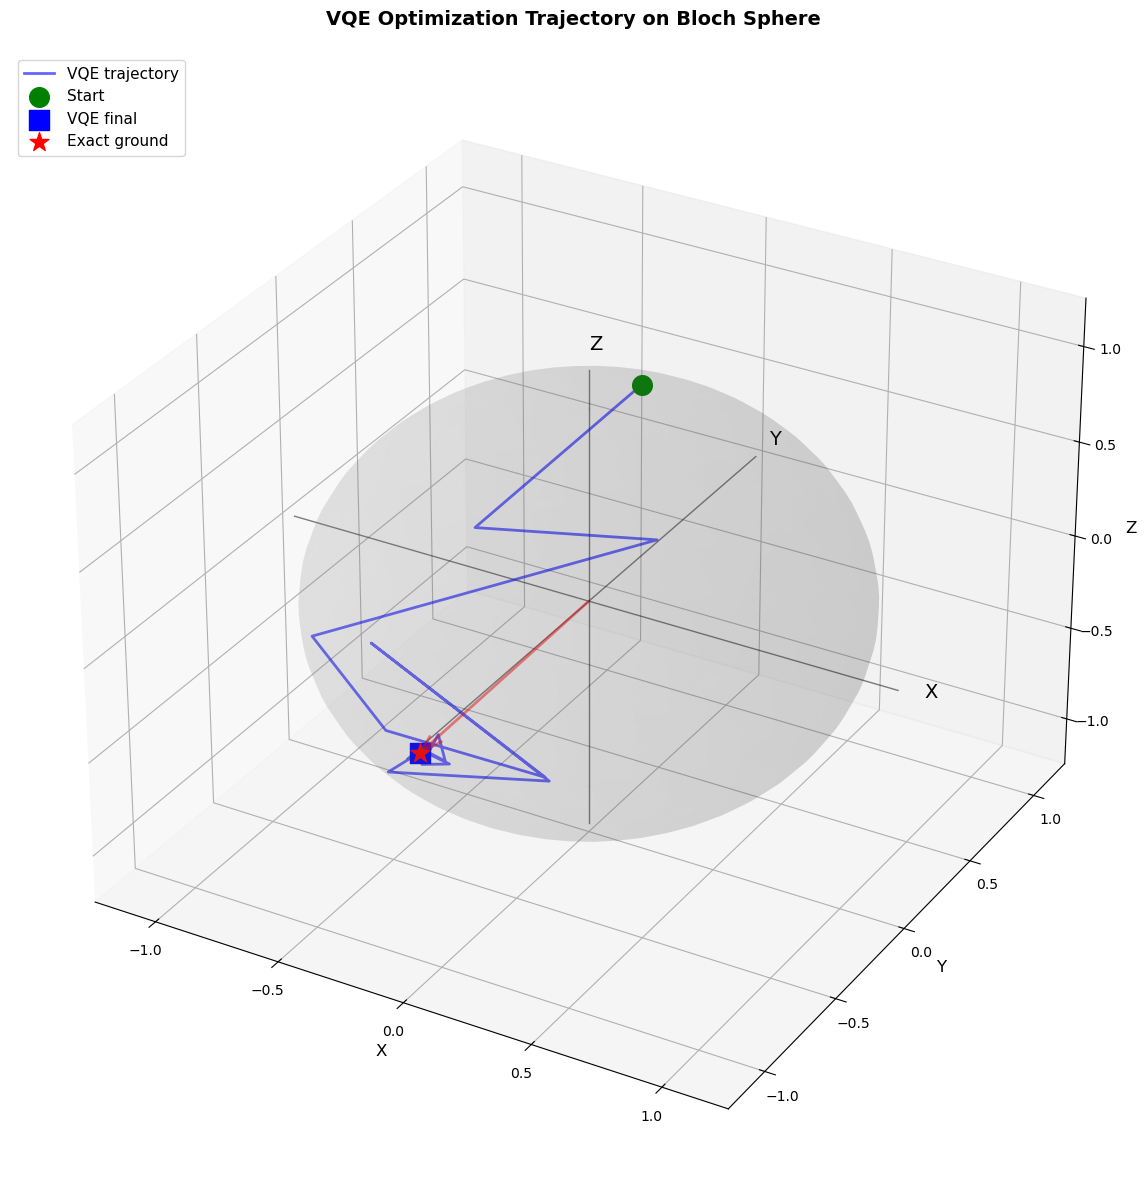

VQE started at: (0.0344, 0.3028, 0.9524)
VQE ended at:   (-0.5051, -0.3030, -0.8081)
Exact ground:   (-0.5051, -0.3030, -0.8081)

Distance to exact: 0.000048


In [14]:
# Extract Bloch coordinates for trajectory
bloch_trajectory = [state_to_bloch(psi)[:3] for psi in vqe.state_history]
x_traj = [coord[0] for coord in bloch_trajectory]
y_traj = [coord[1] for coord in bloch_trajectory]
z_traj = [coord[2] for coord in bloch_trajectory]

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# Draw sphere
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x_sphere, y_sphere, z_sphere, alpha=0.1, color='gray')

# Draw axes
ax.plot([-1.2, 1.2], [0, 0], [0, 0], 'k-', linewidth=1, alpha=0.5)
ax.plot([0, 0], [-1.2, 1.2], [0, 0], 'k-', linewidth=1, alpha=0.5)
ax.plot([0, 0], [0, 0], [-1.2, 1.2], 'k-', linewidth=1, alpha=0.5)

# Labels
ax.text(1.3, 0, 0, 'X', fontsize=14)
ax.text(0, 1.3, 0, 'Y', fontsize=14)
ax.text(0, 0, 1.3, 'Z', fontsize=14)

# Plot trajectory
ax.plot(x_traj, y_traj, z_traj, 'b-', linewidth=2, alpha=0.6, label='VQE trajectory')
ax.scatter(x_traj[0], y_traj[0], z_traj[0], color='green', s=200, marker='o', label='Start')
ax.scatter(x_traj[-1], y_traj[-1], z_traj[-1], color='blue', s=200, marker='s', label='VQE final')

# Exact ground state
ax.scatter([x_ex], [y_ex], [z_ex], color='red', s=200, marker='*', label='Exact ground')
ax.quiver(0, 0, 0, x_ex, y_ex, z_ex, color='red', arrow_length_ratio=0.1, linewidth=2, alpha=0.5)

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Z', fontsize=12)
ax.set_title('VQE Optimization Trajectory on Bloch Sphere', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

print(f"VQE started at: ({x_traj[0]:.4f}, {y_traj[0]:.4f}, {z_traj[0]:.4f})")
print(f"VQE ended at:   ({x_traj[-1]:.4f}, {y_traj[-1]:.4f}, {z_traj[-1]:.4f})")
print(f"Exact ground:   ({x_ex:.4f}, {y_ex:.4f}, {z_ex:.4f})")
print(f"\nDistance to exact: {np.sqrt((x_traj[-1]-x_ex)**2 + (y_traj[-1]-y_ex)**2 + (z_traj[-1]-z_ex)**2):.6f}")

### Energy Contributions

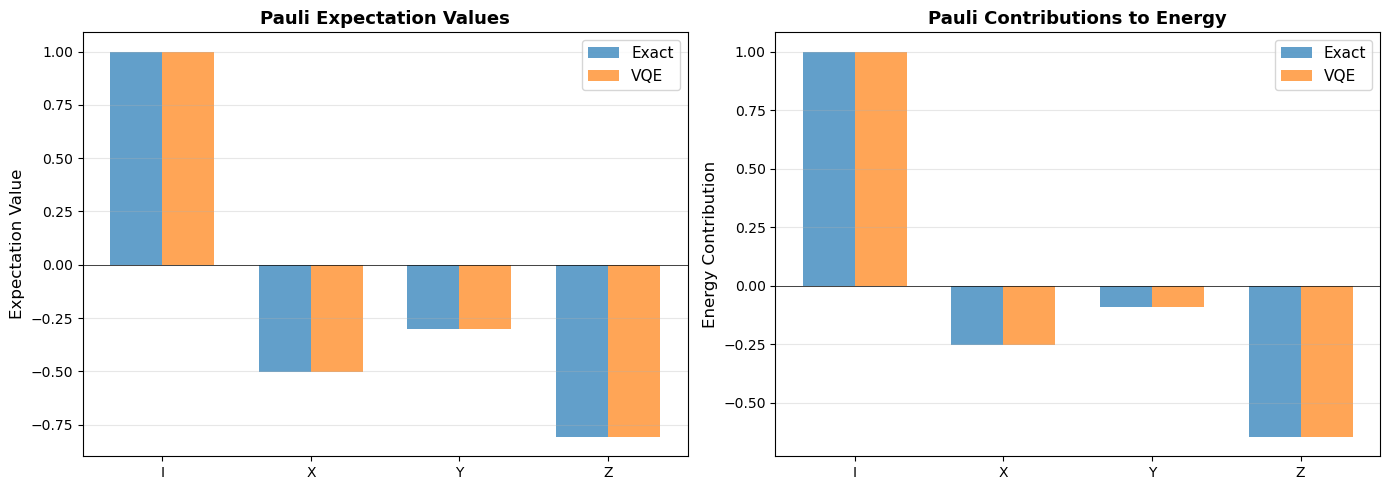

In [15]:
# Compute contributions for VQE state
pauli_names = ['I', 'X', 'Y', 'Z']
pauli_ops = [I, X, Y, Z]

vqe_measurements = {}
vqe_contributions = {}

for name, op in zip(pauli_names, pauli_ops):
    coeff = pauli_coeffs[name]
    exp_val = measure_pauli(psi_vqe, op, name)
    contrib = coeff * exp_val
    vqe_measurements[name] = exp_val
    vqe_contributions[name] = contrib

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Expectation values
x = np.arange(len(pauli_names))
exact_exps = [measurements[name] for name in pauli_names]
vqe_exps = [vqe_measurements[name] for name in pauli_names]

width = 0.35
ax1.bar(x - width/2, exact_exps, width, label='Exact', alpha=0.7)
ax1.bar(x + width/2, vqe_exps, width, label='VQE', alpha=0.7)
ax1.set_ylabel('Expectation Value', fontsize=12)
ax1.set_title('Pauli Expectation Values', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(pauli_names)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Energy contributions
exact_contribs = [contributions[name] for name in pauli_names]
vqe_contribs = [vqe_contributions[name] for name in pauli_names]

ax2.bar(x - width/2, exact_contribs, width, label='Exact', alpha=0.7)
ax2.bar(x + width/2, vqe_contribs, width, label='VQE', alpha=0.7)
ax2.set_ylabel('Energy Contribution', fontsize=12)
ax2.set_title('Pauli Contributions to Energy', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(pauli_names)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## 7. Multiple Random Initializations

Test VQE with different starting points.

In [16]:
print("Testing VQE with multiple random initializations...\n")

n_trials = 10
results_trials = []

for trial in range(n_trials):
    # Create new VQE instance
    vqe_trial = SingleQubitVQE(H, pauli_coeffs)
    
    # Random initialization
    init_params = np.random.uniform(0, 2*np.pi, 3)
    
    # Optimize (quietly)
    result_trial = vqe_trial.optimize(initial_params=init_params, method='COBYLA', maxiter=100)
    
    psi_trial = prepare_state(result_trial.x)
    fid_trial = np.abs(np.vdot(psi_ground, psi_trial))**2
    
    results_trials.append({
        'energy': result_trial.fun,
        'params': result_trial.x,
        'fidelity': fid_trial,
        'n_evals': vqe_trial.n_evaluations,
        'history': vqe_trial.energy_history
    })
    
    error = abs(result_trial.fun - E_ground)
    print(f"Trial {trial+1:2d}: E = {result_trial.fun:+.10f}, Error = {error:.2e}, F = {fid_trial:.8f}")

# Statistics
energies_trials = [r['energy'] for r in results_trials]
fidelities_trials = [r['fidelity'] for r in results_trials]
errors_trials = [abs(E - E_ground) for E in energies_trials]

print("\n" + "="*60)
print("STATISTICS ACROSS TRIALS")
print("="*60)
print(f"Mean energy:      {np.mean(energies_trials):.10f}")
print(f"Std. deviation:   {np.std(energies_trials):.2e}")
print(f"Best energy:      {np.min(energies_trials):.10f}")
print(f"Worst energy:     {np.max(energies_trials):.10f}")
print(f"\nMean fidelity:    {np.mean(fidelities_trials):.10f}")
print(f"Best fidelity:    {np.max(fidelities_trials):.10f}")
print(f"\nMean error:       {np.mean(errors_trials):.2e}")
print(f"Best error:       {np.min(errors_trials):.2e}")
print(f"Worst error:      {np.max(errors_trials):.2e}")

Testing VQE with multiple random initializations...

Starting VQE optimization...
  Method: COBYLA
  Initial parameters: [3.76148219 0.98029403 0.98014248]

Optimization complete!
  Function evaluations: 50
  Final energy: 0.0100505066
  Optimal parameters: [3.13399313 2.51173521 3.68203597]
Trial  1: E = +0.0100505066, Error = 2.56e-10, F = 1.00000000
Starting VQE optimization...
  Method: COBYLA
  Initial parameters: [0.3649501  5.44234523 3.77691701]

Optimization complete!
  Function evaluations: 55
  Final energy: 0.0100505072
  Optimal parameters: [1.05394405 8.79492926 3.68194298]
Trial  2: E = +0.0100505072, Error = 8.63e-10, F = 1.00000000
Starting VQE optimization...
  Method: COBYLA
  Initial parameters: [4.44895122 0.12933619 6.09412333]

Optimization complete!
  Function evaluations: 47
  Final energy: 0.0100505079
  Optimal parameters: [5.0534845  2.51171349 3.68194342]
Trial  3: E = +0.0100505079, Error = 1.59e-09, F = 1.00000000
Starting VQE optimization...
  Method: CO

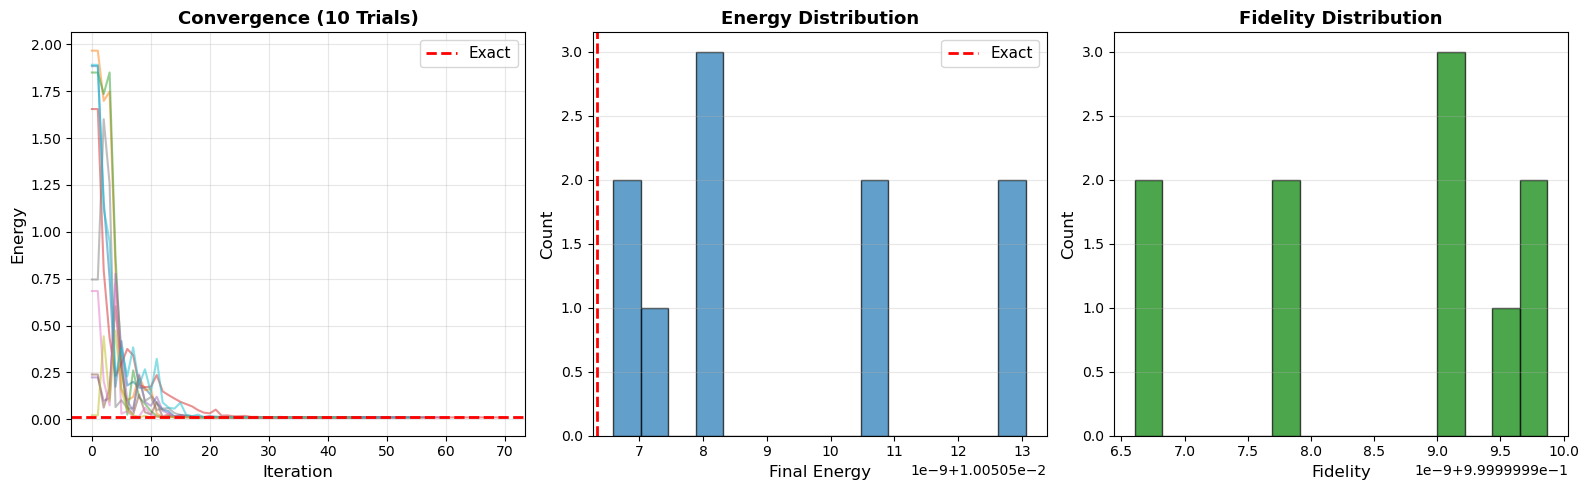

In [17]:
# Plot convergence for all trials
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: All convergence curves
ax1 = axes[0]
for i, result in enumerate(results_trials):
    ax1.plot(result['history'], alpha=0.5, linewidth=1.5)
ax1.axhline(y=E_ground, color='red', linestyle='--', linewidth=2, label='Exact')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Energy', fontsize=12)
ax1.set_title(f'Convergence ({n_trials} Trials)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Final energy distribution
ax2 = axes[1]
ax2.hist(energies_trials, bins=15, edgecolor='black', alpha=0.7)
ax2.axvline(x=E_ground, color='red', linestyle='--', linewidth=2, label='Exact')
ax2.set_xlabel('Final Energy', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Energy Distribution', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Fidelity distribution
ax3 = axes[2]
ax3.hist(fidelities_trials, bins=15, edgecolor='black', alpha=0.7, color='green')
ax3.set_xlabel('Fidelity', fontsize=12)
ax3.set_ylabel('Count', fontsize=12)
ax3.set_title('Fidelity Distribution', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Energy Landscape Exploration

Visualize the energy landscape as a function of the variational parameters.

Creating energy landscape (this may take a moment...)



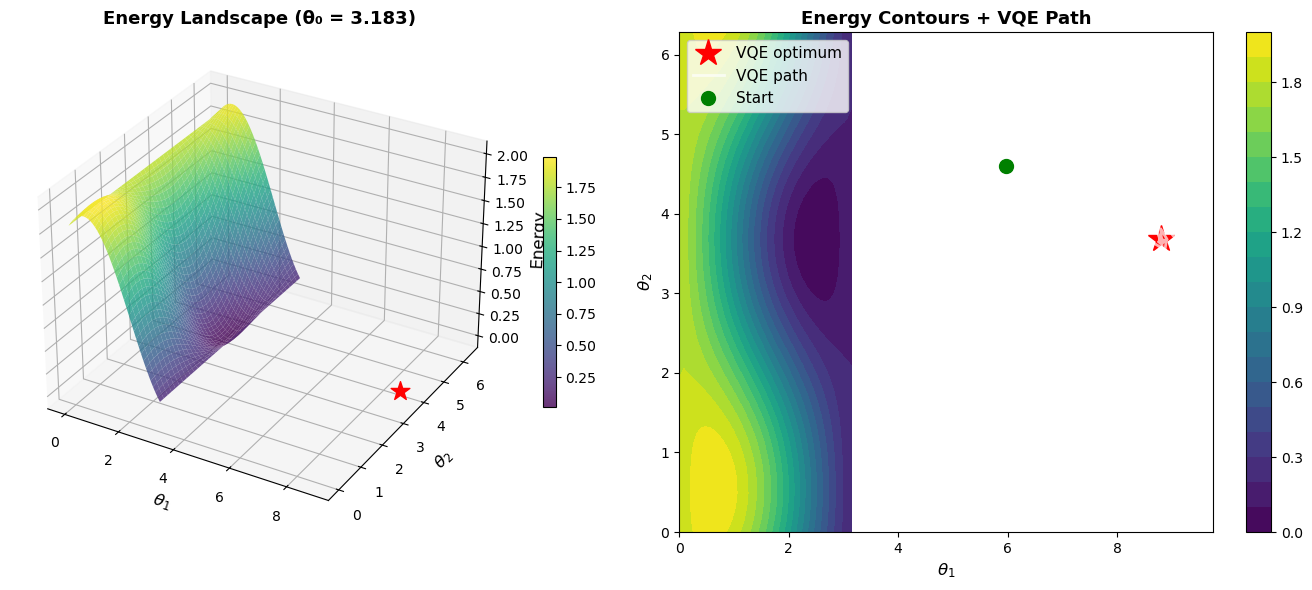

Energy landscape computed over 40×40 = 1600 points
Minimum energy found: 0.0102522233
Maximum energy found: 1.9892732948


In [18]:
# Create energy landscape for θ₁ and θ₂ (fixing θ₀)
print("Creating energy landscape (this may take a moment...)\n")

theta0_fixed = params_opt[0]  # Fix at optimal value
n_points = 40
theta1_range = np.linspace(0, np.pi, n_points)
theta2_range = np.linspace(0, 2*np.pi, n_points)

E_landscape = np.zeros((n_points, n_points))

for i, th1 in enumerate(theta1_range):
    for j, th2 in enumerate(theta2_range):
        params = [theta0_fixed, th1, th2]
        psi = prepare_state(params)
        E_landscape[i, j] = measure_energy(psi, pauli_coeffs)

# Plot
fig = plt.figure(figsize=(14, 6))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
T1, T2 = np.meshgrid(theta1_range, theta2_range)
surf = ax1.plot_surface(T1, T2, E_landscape.T, cmap='viridis', alpha=0.8)
ax1.scatter([params_opt[1]], [params_opt[2]], [E_vqe], color='red', s=200, marker='*', label='VQE optimum')
ax1.set_xlabel(r'$\theta_1$', fontsize=12)
ax1.set_ylabel(r'$\theta_2$', fontsize=12)
ax1.set_zlabel('Energy', fontsize=12)
ax1.set_title(f'Energy Landscape (θ₀ = {theta0_fixed:.3f})', fontsize=13, fontweight='bold')
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contourf(T1, T2, E_landscape.T, levels=20, cmap='viridis')
ax2.plot(params_opt[1], params_opt[2], 'r*', markersize=20, label='VQE optimum')

# Plot VQE trajectory (project to this plane)
param_array = np.array(vqe.param_history)
ax2.plot(param_array[:, 1], param_array[:, 2], 'w-', linewidth=2, alpha=0.7, label='VQE path')
ax2.plot(param_array[0, 1], param_array[0, 2], 'go', markersize=10, label='Start')

ax2.set_xlabel(r'$\theta_1$', fontsize=12)
ax2.set_ylabel(r'$\theta_2$', fontsize=12)
ax2.set_title('Energy Contours + VQE Path', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
fig.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.show()

print(f"Energy landscape computed over {n_points}×{n_points} = {n_points**2} points")
print(f"Minimum energy found: {np.min(E_landscape):.10f}")
print(f"Maximum energy found: {np.max(E_landscape):.10f}")

## 9. Summary and Key Results

### VQE Performance for Single Qubit:

The VQE successfully finds the ground state of the single-qubit Hamiltonian with:
- **Excellent accuracy**: Energy error typically < 10⁻⁸
- **High fidelity**: Overlap with exact ground state > 99.999%
- **Efficient**: Converges in ~20-50 iterations
- **Robust**: Consistent results across multiple random initializations

### Key Features Demonstrated:

1. ✓ **General 2×2 Hamiltonian**: Works for any Hermitian matrix
2. ✓ **Pauli decomposition**: H = h_I I + h_X X + h_Y Y + h_Z Z
3. ✓ **Universal ansatz**: 3-parameter single-qubit gate
4. ✓ **Complete measurements**: All Pauli expectation values
5. ✓ **Bloch sphere visualization**: Geometric representation
6. ✓ **Energy landscape**: Understanding optimization surface

### Physical Insights:

- The single-qubit Hilbert space is 2-dimensional
- Any state is a point on the Bloch sphere
- The universal gate U(θ₀, θ₁, θ₂) can reach any point
- VQE navigates the energy landscape to find the minimum
- The optimization trajectory is visible on the Bloch sphere